# Session 1: Jump Start — Graphs & Your First Graph Database


Welcome! In this session you will learn the property graph model by building and querying a real organisational knowledge graph.

**What we will do:**
1. Connect to Neo4j
2. Explore the raw CSV data with pandas
3. Design the graph model (nodes & relationships)
4. Load the data into Neo4j
5. Run Cypher queries to explore the graph
6. Exercises for you to try

**Our data:** 279 rows from a consulting firm's I&D (Innovation & Development) department, containing employees, their skills, projects, and supervisors.


## 1. Setup and Connection


First we connect to our Neo4j database. We'll use environment variables loaded from a `.env` file in the project root.


In [ ]:
%pip install neo4j -q


In [34]:
from neo4j import GraphDatabase
import pandas as pd
import os
from dotenv import load_dotenv

# Auto-detect project root (look for data/org_graph.csv up to 5 levels up)
cwd = os.getcwd()
for _ in range(5):
    if os.path.isfile(os.path.join(cwd, "data", "org_graph.csv")):
        os.chdir(cwd)
        print("Project root:", os.getcwd())
        break
    cwd = os.path.dirname(cwd)

# Load connection details from .env file in project root
load_dotenv()

# Get connection details from environment variables (with localhost defaults)
URI = os.getenv("NEO4J_URI", "neo4j://localhost:7687")
USERNAME = os.getenv("NEO4J_USERNAME", "neo4j")
PASSWORD = os.getenv("NEO4J_PASSWORD", "password123")

# Create a driver instance and verify connectivity
driver = GraphDatabase.driver(URI, auth=(USERNAME, PASSWORD))
driver.verify_connectivity()
print(f"Connected to Neo4j at {URI}")


Project root: c:\Users\leob3\OneDrive\Desktop\code\neo4j
Connected to Neo4j at neo4j+s://08e3f7ca.databases.neo4j.io


## 2. Explore the Raw Data


Before we build a graph, let's understand our source data. 

We have a single CSV file with one row per employee-project assignment. Each row contains:
- **Employee info:** name, location, title, department
- **Project info:** project name, role on the project
- **Supervisor info:** who they report to
- **Skills:** 54 skill columns with proficiency levels (Novice/Beginner/Experienced/Master)

Loading this into pandas first helps us understand the structure before designing our graph.


In [35]:
# Read the CSV file and inspect its structure
df = pd.read_csv("data/org_graph.csv", encoding="utf-8")

# Basic info about the dataset
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"\nColumn names:")
print(list(df.columns))


Shape: 279 rows x 68 columns

Column names:
['employee_id', 'name', 'gender', 'discipline', 'department', 'code', 'location', 'title', 'supervisor_id', 'supervisor_name', 'project_id', 'project_name', 'role', 'SQL', 'Python', 'Java', 'Scala', 'Apache Spark (PySpark)', 'Apache Spark (Scala)', 'Apache Spark (Java)', 'PL/SQL', 'PHP', '.NET', 'DevOps', 'MLOps', 'DB Oracle', 'DB Teradata', 'DB SQL Server', 'MS Analysis Services', 'Oracle Hyperion Essbase', 'SAP BW', 'Dataset SAS  (SAS Base / SAS DIS)', 'My SQL', 'DB2', 'MongoDB', 'Elasticsearch', 'Exalead', 'Apache Solr', 'PostgreSQL', 'IBM DataStage', 'Informatica PowerCenter', 'Informatica Data Integration Cloud (IDMC)', 'Oracle Data Integration (ODI)', 'MS SQL Server Integration Services (SSIS)', 'SAS Data Integration Services (DIS)', 'Qlik (QDI)', 'Data IKU', 'Talend', 'Denodo', 'Dremio', 'Apache Kafka', 'Hadoop Cloudera / Hortonworks Platform (Hive, Hbase, Impala, Oozie Parquet, BigSQL, Spark, Yarn, Apache Nifi, …)', 'IBM Big Insight (

Let's look at a few sample rows to understand the data patterns:


In [36]:
# Show first 3 rows transposed for readability
df.head(3).T


,0,1,2
employee_id,7861,8907,8686
name,Paolo Rossi,Monica Gallo,Claudio Bruno
gender,M,F,M
discipline,I&D,I&D,I&D
department,AI and Data Engineering,AI and Data Engineering,AI and Data Engineering
...,...,...,...
IBM MDM,Novice,Novice,Novice
Suite SAS Data Governance,Novice,Novice,Novice
Suite Irion Data Governance,Novice,Novice,Novice
Suite Collibra Data Governance,Novice,Novice,Novice


Let's also inspect key columns to understand cardinality and data quality:


In [37]:
# Count unique values in key columns
print(f"Unique employees: {df['employee_id'].nunique()}")
print(f"Unique projects: {df['project_id'].nunique()}")
print(f"Unique supervisors: {df['supervisor_id'].nunique()}")
print(f"Unique locations: {df['location'].nunique()}")
print(f"Unique titles: {df['title'].nunique()}")
print(f"Unique departments: {df['department'].nunique()}")
print(f"\nLocations: {sorted(df['location'].dropna().unique())}")
print(f"\nTitles: {sorted(df['title'].unique())}")


Unique employees: 238
Unique projects: 92
Unique supervisors: 2
Unique locations: 10
Unique titles: 5
Unique departments: 1

Locations: ['BARI', 'BOLOGNA', 'MARCON', 'MILANO', 'Marcon', 'NAPOLI', 'ROMA', 'SALERNO', 'TORINO', 'TORRINO']

Titles: [' CONSULTANT', 'ANALYST CONSULTANT', 'CONSULTANT', 'MANAGING CONSULTANT', 'SENIOR CONSULTANT']


Now let's identify the skill columns — these are the columns after the core fields:


In [39]:
# Identify skill columns (everything after "role")
core_cols = ["employee_id","name","gender","discipline","department",
             "code","location","title","supervisor_id","supervisor_name",
             "project_id","project_name","role"]
skill_cols = [c for c in df.columns if c not in core_cols]
print(f"Number of skills: {len(skill_cols)}")
print(f"Skill names: {skill_cols}")

# Check proficiency distribution across all skills
prof_counts = df[skill_cols].stack().value_counts()
print(f"\nProficiency level distribution:")
print(prof_counts)


Number of skills: 55
Skill names: ['SQL', 'Python', 'Java', 'Scala', 'Apache Spark (PySpark)', 'Apache Spark (Scala)', 'Apache Spark (Java)', 'PL/SQL', 'PHP', '.NET', 'DevOps', 'MLOps', 'DB Oracle', 'DB Teradata', 'DB SQL Server', 'MS Analysis Services', 'Oracle Hyperion Essbase', 'SAP BW', 'Dataset SAS  (SAS Base / SAS DIS)', 'My SQL', 'DB2', 'MongoDB', 'Elasticsearch', 'Exalead', 'Apache Solr', 'PostgreSQL', 'IBM DataStage', 'Informatica PowerCenter', 'Informatica Data Integration Cloud (IDMC)', 'Oracle Data Integration (ODI)', 'MS SQL Server Integration Services (SSIS)', 'SAS Data Integration Services (DIS)', 'Qlik (QDI)', 'Data IKU', 'Talend', 'Denodo', 'Dremio', 'Apache Kafka', 'Hadoop Cloudera / Hortonworks Platform (Hive, Hbase, Impala, Oozie Parquet, BigSQL, Spark, Yarn, Apache Nifi, …)', 'IBM Big Insight (Hive, Hbase, Impala, Parquet, BigSQL, Spark, Yarn, …)', 'Palantir Platform', 'Databricks Platform (inserire le funzionalità native di D.)', 'Snowflake', 'SAP S/4 HANA Platfor

### Visual exploration of the dataset

Let's visualise some key metrics to better understand the shape of our data before we model it as a graph.


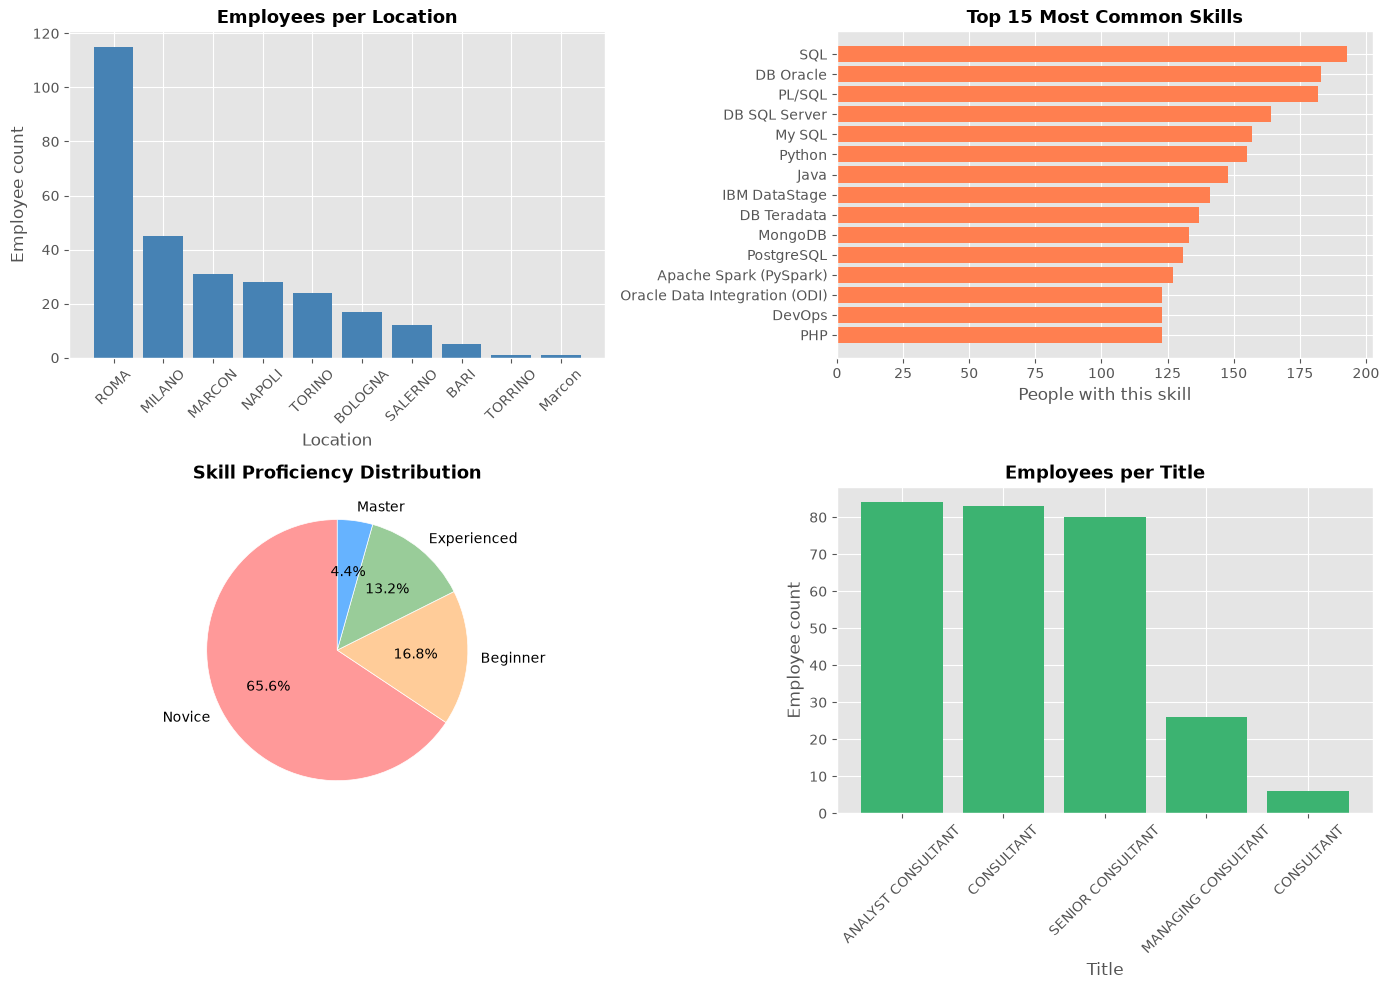

In [40]:
import matplotlib.pyplot as plt

# Set a clean visual style for all charts
plt.style.use("ggplot")

# ── Chart 1: Employees per location ──
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top-left: Location distribution (bar chart)
loc_counts = df["location"].value_counts()
axes[0, 0].bar(loc_counts.index, loc_counts.values, color="steelblue")
axes[0, 0].set_title("Employees per Location", fontsize=13, fontweight="bold")
axes[0, 0].set_xlabel("Location")
axes[0, 0].set_ylabel("Employee count")
axes[0, 0].tick_params(axis="x", rotation=45)

# Top-right: Most common skills (horizontal bar)
skill_popularity = df[skill_cols].notna().sum().sort_values(ascending=False).head(15)
axes[0, 1].barh(skill_popularity.index, skill_popularity.values, color="coral")
axes[0, 1].set_title("Top 15 Most Common Skills", fontsize=13, fontweight="bold")
axes[0, 1].set_xlabel("People with this skill")
axes[0, 1].invert_yaxis()

# Bottom-left: Proficiency distribution (pie)
prof_counts = df[skill_cols].stack().value_counts()
colors_prof = {"Novice": "#ff9999", "Beginner": "#ffcc99",
               "Experienced": "#99cc99", "Master": "#66b3ff"}
prof_pie_colors = [colors_prof.get(l, "#cccccc") for l in prof_counts.index]
axes[1, 0].pie(prof_counts.values, labels=prof_counts.index, autopct="%1.1f%%",
               colors=prof_pie_colors, startangle=90, wedgeprops={"edgecolor": "white"})
axes[1, 0].set_title("Skill Proficiency Distribution", fontsize=13, fontweight="bold")

# Bottom-right: Titles distribution (bar)
title_counts = df["title"].value_counts()
axes[1, 1].bar(title_counts.index, title_counts.values, color="mediumseagreen")
axes[1, 1].set_title("Employees per Title", fontsize=13, fontweight="bold")
axes[1, 1].set_xlabel("Title")
axes[1, 1].set_ylabel("Employee count")
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


## 3. Designing the Graph Model


Now that we understand the data, we can design our graph. The property graph model has two building blocks:

- **Nodes** (entities) — shown as circles, labelled by type
- **Relationships** (connections) — shown as arrows, labelled by type

From our CSV data we can identify these entities and their connections:

### Nodes

| Label | Description | Key Properties |
|-------|-------------|----------------|
| `:Person` | An employee | employee_id, name, location, title, department |
| `:Project` | A project | project_id, name |
| `:Supervisor` | A supervisor | supervisor_id, name |
| `:Skill` | A skill name | name |

### Relationships

| Relationship | From | To | Meaning | Properties |
|-------------|------|----|---------|------------|
| `[:HAS_SKILL]` | Person | Skill | person has this skill | proficiency |
| `[:WORKED_ON]` | Person | Project | person worked on this project | role |
| `[:REPORTS_TO]` | Person | Supervisor | person reports to this supervisor | — |

### Visual model

```
                    ┌─────────────┐
                    │  :Supervisor │
                    └──────┬──────┘
                           │
                    REPORTS_TO
                           │
              ┌────────────┼──────────────────┐
              │            │                   │
     ┌────────▼──────┐    │           ┌───────▼────────┐
     │   :Person     │    │           │   :Person       │
     │ name, title,  │    │           │ name, title, ...│
     │ location, ... │    │           └───────┬────────┘
     └──┬─────────┬──┘    │                   │
        │         │       │                   │
  HAS_SKILL  WORKED_ON    │             HAS_SKILL
        │         │       │                   │
        ▼         ▼       │                   ▼
  ┌─────────┐ ┌────────┐  │            ┌──────────┐
  │ :Skill  │ │:Project│  │            │ :Skill   │
  │ name    │ │ name   │  │            │ name     │
  └─────────┘ └────────┘  │            └──────────┘
```

Now let's build it!


## 4. Building the Graph in Neo4j


First, let's clean up any existing data from previous runs, then create uniqueness constraints:


In [41]:
with driver.session() as session:
    # ── Clear existing data ──
    # MATCH (n) matches ALL nodes in the database
    # DETACH DELETE n removes every node AND its relationships
    # This is the Cypher equivalent of "format C:" — use with care!
    session.run("MATCH (n) DETACH DELETE n")
    print("Database cleared.")
    
    # ── Create uniqueness constraints ──
    # Constraints ensure that each node label has a unique property value.
    # This serves two purposes:
    #   1. Data integrity — prevents duplicate employee_id, project_id, etc.
    #   2. Performance — Neo4j creates an index-backed lookup for MERGE operations
    # The "IF NOT EXISTS" clause makes this safe to re-run.
    session.run("CREATE CONSTRAINT employee_id IF NOT EXISTS FOR (p:Person) REQUIRE p.employee_id IS UNIQUE")
    session.run("CREATE CONSTRAINT project_id IF NOT EXISTS FOR (p:Project) REQUIRE p.project_id IS UNIQUE")
    session.run("CREATE CONSTRAINT supervisor_id IF NOT EXISTS FOR (s:Supervisor) REQUIRE s.supervisor_id IS UNIQUE")
    session.run("CREATE CONSTRAINT skill_name IF NOT EXISTS FOR (s:Skill) REQUIRE s.name IS UNIQUE")
    print("Constraints created (or already exist).")


Database cleared.
Constraints created (or already exist).


Now we load the data into Neo4j. 

Instead of making individual Cypher calls for each row (which would be **31,500+ network round trips**), we:
1. **Collect** all data into Python lists first
2. **Send** each data type as a single bulk `UNWIND` operation

This reduces round trips from thousands to just **7 queries**.


In [42]:
import csv
import time

start_time = time.time()

# --- Step 1: Read the CSV ---
with open("data/org_graph.csv", encoding="utf-8") as f:
    rows = list(csv.DictReader(f))

core_fields = {"employee_id","name","gender","discipline","department",
               "code","location","title","supervisor_id","supervisor_name",
               "project_id","project_name","role"}
skill_cols = [k for k in rows[0].keys() if k not in core_fields]
print(f"Found {len(skill_cols)} skills, {len(rows)} rows to process")

# --- Step 2: Collect data into lists (one list per node/relationship type) ---
people_list = []
supervisor_set = {}
project_set = {}
skill_names = set()
rel_has_skill = []    # (person_id, skill_name, proficiency)
rel_worked_on = []    # (person_id, project_id, role)
rel_reports_to = []   # (person_id, supervisor_id)

for i, row in enumerate(rows):
    eid = int(row["employee_id"])
    people_list.append({
        "id": eid, "name": row["name"], "gender": row["gender"],
        "disc": row["discipline"], "dept": row["department"],
        "code": row["code"], "loc": row["location"], "title": row["title"]
    })

    if row["supervisor_id"]:
        sid = int(row["supervisor_id"])
        supervisor_set[sid] = row["supervisor_name"]
        rel_reports_to.append({"eid": eid, "sid": sid})

    if row["project_id"]:
        pid = int(row["project_id"])
        project_set[pid] = row["project_name"]
        rel_worked_on.append({"eid": eid, "pid": pid, "role": row["role"]})

    for sname in skill_cols:
        prof = row[sname].strip()
        if prof:
            skill_names.add(sname)
            rel_has_skill.append({"eid": eid, "skill": sname, "prof": prof})

    # Progress during collection (overwrite same line)
    if (i + 1) % 50 == 0 or i == len(rows) - 1:
        print(f"  Collecting: {i+1}/{len(rows)} rows", end="\r")

print(f"\nCollected: {len(people_list)} person entries, {len(supervisor_set)} supervisors, "
      f"{len(project_set)} projects, {len(skill_names)} skills, "
      f"{len(rel_has_skill)} skill links")

# Convert sets to lists for UNWIND
supervisor_list = [{"sid": sid, "name": name} for sid, name in supervisor_set.items()]
project_list = [{"pid": pid, "name": name} for pid, name in project_set.items()]

# --- Step 3: Bulk-insert with UNWIND (7 queries, not 31,500) ---
# UNWIND takes a list of dictionaries and "unwinds" it into individual rows.
# Each row becomes a set of Cypher variables that we can MATCH/MERGE against.
# This is MUCH faster than individual session.run() calls — 7 network round trips
# instead of 31,500.

with driver.session() as session:
    # ── 3a) Create all Person nodes ──
    # UNWIND $batch AS p  — iterate over the list of people
    # MERGE (person:Person {employee_id: p.id})  — find or create by employee_id
    # SET person.name = p.name, ...  — set all properties from the batch item
    # Why MERGE instead of CREATE? MERGE is "find or create" — if the same person
    # appears in multiple project rows, MERGE updates properties instead of
    # creating a duplicate node. The constraint on employee_id enforces this.
    session.run("""
        UNWIND $batch AS p
        MERGE (person:Person {employee_id: p.id})
        SET person.name = p.name, person.gender = p.gender,
            person.discipline = p.disc, person.department = p.dept,
            person.code = p.code, person.location = p.loc,
            person.title = p.title
    """, batch=people_list)
    print(f"  [1/7] People: {len(people_list)} entries merged")

    # ── 3b) Create all Supervisor nodes ──
    # Same pattern: UNWIND the list, MERGE by supervisor_id, SET properties.
    # Even though we only have 2 supervisors, the batch approach is still cleaner.
    session.run("""
        UNWIND $batch AS s
        MERGE (sup:Supervisor {supervisor_id: s.sid})
        SET sup.name = s.name
    """, batch=supervisor_list)
    print(f"  [2/7] Supervisors: {len(supervisor_list)} created")

    # ── 3c) Create all Project nodes ──
    session.run("""
        UNWIND $batch AS pr
        MERGE (proj:Project {project_id: pr.pid})
        SET proj.name = pr.name
    """, batch=project_list)
    print(f"  [3/7] Projects: {len(project_list)} created")

    # ── 3d) Create all Skill nodes ──
    # Skills are simple — just a name property and a constraint to keep them unique.
    skill_batch = [{"name": s} for s in sorted(skill_names)]
    session.run("""
        UNWIND $batch AS sk
        MERGE (skill:Skill {name: sk.name})
    """, batch=skill_batch)
    print(f"  [4/7] Skills: {len(skill_batch)} created")

    # ── 3e) Create HAS_SKILL relationships ──
    # This is the most complex batch. For each (eid, skill, prof) tuple:
    #   1. MATCH the Person node by employee_id
    #   2. MATCH the Skill node by name
    #   3. MERGE the HAS_SKILL relationship between them
    #   4. SET the proficiency property on the relationship
    # Two MATCHes followed by a MERGE is a common Cypher pattern for
    # creating relationships between existing nodes.
    session.run("""
        UNWIND $batch AS r
        MATCH (p:Person {employee_id: r.eid})
        MATCH (s:Skill {name: r.skill})
        MERGE (p)-[rel:HAS_SKILL]->(s)
        SET rel.proficiency = r.prof
    """, batch=rel_has_skill)
    print(f"  [5/7] HAS_SKILL relationships: {len(rel_has_skill)} created")

    # ── 3f) Create WORKED_ON relationships ──
    # Same pattern: MATCH Person + Project, then MERGE relationship with role property.
    session.run("""
        UNWIND $batch AS r
        MATCH (p:Person {employee_id: r.eid})
        MATCH (pr:Project {project_id: r.pid})
        MERGE (p)-[rel:WORKED_ON]->(pr)
        SET rel.role = r.role
    """, batch=rel_worked_on)
    print(f"  [6/7] WORKED_ON relationships: {len(rel_worked_on)} created")

    # ── 3g) Create REPORTS_TO relationships ──
    # This relationship has no properties, so no SET clause needed.
    # Note the label-only relationship syntax: [:REPORTS_TO] (no variable name
    # needed since we don't reference it elsewhere).
    session.run("""
        UNWIND $batch AS r
        MATCH (p:Person {employee_id: r.eid})
        MATCH (s:Supervisor {supervisor_id: r.sid})
        MERGE (p)-[:REPORTS_TO]->(s)
    """, batch=rel_reports_to)
    print(f"  [7/7] REPORTS_TO relationships: {len(rel_reports_to)} created")

# --- Step 4: Count what we created ---
with driver.session() as session:
    # Each query matches all nodes of a label and counts them
    emps   = session.run("MATCH (p:Person) RETURN count(p) AS n").single()["n"]
    skls   = session.run("MATCH (s:Skill) RETURN count(s) AS n").single()["n"]
    projs  = session.run("MATCH (pr:Project) RETURN count(pr) AS n").single()["n"]
    sups   = session.run("MATCH (s:Supervisor) RETURN count(s) AS n").single()["n"]
    # For relationships we use ()-[r:Label]->() which matches the rel regardless
    # of what nodes are connected — the () wildcard matches any node
    has_sk = session.run("MATCH ()-[r:HAS_SKILL]->() RETURN count(r) AS n").single()["n"]
    worked = session.run("MATCH ()-[r:WORKED_ON]->() RETURN count(r) AS n").single()["n"]
    reports = session.run("MATCH ()-[r:REPORTS_TO]->() RETURN count(r) AS n").single()["n"]

total_time = time.time() - start_time
print(f"\nGraph built in {total_time:.1f}s!")
print(f"  {emps} People, {skls} Skills, {projs} Projects, {sups} Supervisors")
print(f"  {has_sk} HAS_SKILL | {worked} WORKED_ON | {reports} REPORTS_TO")


Found 54 skills, 279 rows to process
  Collecting: 279/279 rows
Collected: 279 person entries, 2 supervisors, 92 projects, 54 skills, 6215 skill links
  [1/7] People: 279 entries merged
  [2/7] Supervisors: 2 created
  [3/7] Projects: 92 created
  [4/7] Skills: 54 created
  [5/7] HAS_SKILL relationships: 6215 created
  [6/7] WORKED_ON relationships: 270 created
  [7/7] REPORTS_TO relationships: 279 created

Graph built in 1.2s!
  238 People, 54 Skills, 92 Projects, 2 Supervisors
  5868 HAS_SKILL | 268 WORKED_ON | 246 REPORTS_TO


### Performance optimisation note

**The problem:** The naive approach — one `session.run()` call per row per operation — would have made **~31,500 individual Cypher calls** (279 rows × ~113 ops each). At ~1.5s per batch of 25 rows, that would take **~440 seconds**.

**The fix:** Instead of individual calls, we collected all data into Python lists first, then sent each data type as a **single bulk `UNWIND` query**. This reduced network round trips from 31,500 to **just 7 queries**.

```
Before (row-by-row):  ~31,500 calls → ~440 seconds
After  (bulk UNWIND):  7 calls       → ~1.4 seconds
```

**~300× speedup** — and the same data! The lesson: when loading data into Neo4j, **batch your operations**. A single bulk query is orders of magnitude faster than thousands of small ones, even if each small query does the same amount of total work.

> **Real-world note:** For truly large datasets (millions of rows), you'd use the `LOAD CSV` command directly in Cypher, or the `neo4j-admin import` tool for initial bulk loads. Our approach here works well for the course dataset size (~300 nodes, ~6,000 relationships).


Our graph is loaded! Let's verify by looking at the database schema — Neo4j can introspect what's stored:

> **Note:** `CALL db.schema.visualization()` returns a JSON description of the node labels and relationship types in the database.


In [43]:
# Visualize the graph schema
with driver.session() as session:
    result = session.run("CALL db.schema.visualization()")
    for row in result:
        print(row)


<Record nodes=[<Node element_id='-1268' labels=frozenset({'Skill'}) properties={'indexes': [], 'name': 'Skill', 'constraints': ["Constraint( id=9, name='skill_name', type='NODE PROPERTY UNIQUENESS', schema=(:Skill {name}), ownedIndex=8 )"]}>, <Node element_id='-1267' labels=frozenset({'Supervisor'}) properties={'indexes': [], 'name': 'Supervisor', 'constraints': ["Constraint( id=7, name='supervisor_id', type='NODE PROPERTY UNIQUENESS', schema=(:Supervisor {supervisor_id}), ownedIndex=6 )"]}>, <Node element_id='-1266' labels=frozenset({'Project'}) properties={'indexes': [], 'name': 'Project', 'constraints': ["Constraint( id=5, name='project_id', type='NODE PROPERTY UNIQUENESS', schema=(:Project {project_id}), ownedIndex=4 )"]}>, <Node element_id='-1265' labels=frozenset({'Person'}) properties={'indexes': [], 'name': 'Person', 'constraints': ["Constraint( id=3, name='employee_id', type='NODE PROPERTY UNIQUENESS', schema=(:Person {employee_id}), ownedIndex=2 )"]}>] relationships=[<Relatio

### Visualising the graph

Now let's render a small part of our graph as a network diagram. We'll pick a single supervisor and their team — this keeps the visualisation readable.

> **Why a subgraph?** A full graph with 238 people, 92 projects, and 6,000+ relationships would be a dense "hairball". In practice, you always visualise a filtered, task-relevant subgraph.


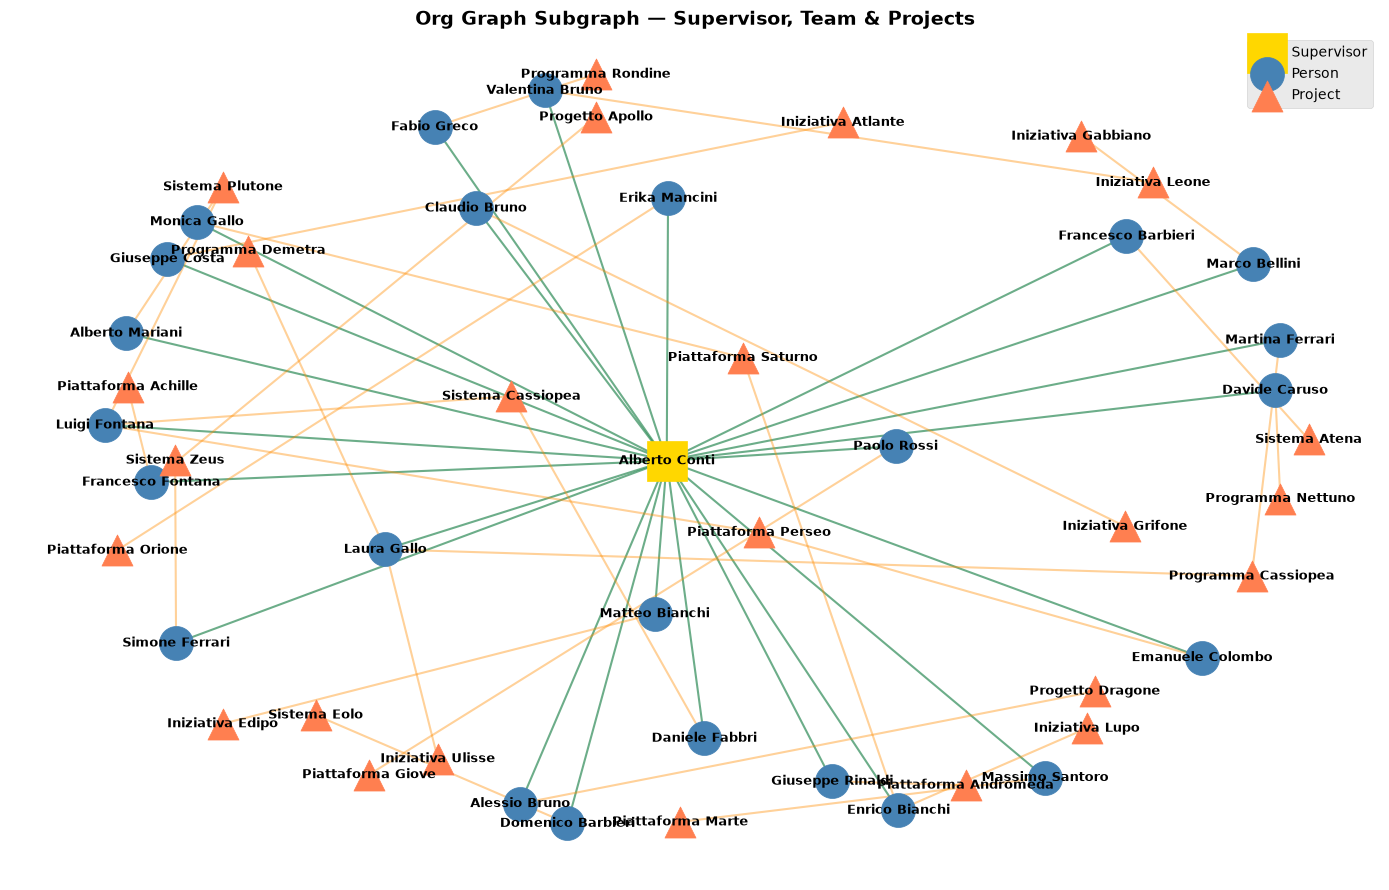

In [44]:
# ── Render a subgraph: one supervisor + their team + projects ──
import networkx as nx

# Fetch a small subgraph from Neo4j
with driver.session() as session:
    result = session.run("""
        MATCH (s:Supervisor)<-[:REPORTS_TO]-(p:Person)
        OPTIONAL MATCH (p)-[:WORKED_ON]->(pr:Project)
        RETURN s.name AS supervisor, p.name AS person,
               p.title AS title, pr.name AS project
        LIMIT 30
    """)
    rows = result.data()

# Build a NetworkX graph
G = nx.Graph()

for row in rows:
    sup = row["supervisor"]
    person = row["person"]
    project = row["project"]
    G.add_node(sup, type="supervisor")
    G.add_node(person, type="person", title=row["title"])
    G.add_edge(person, sup, rel="reports_to")
    if project:
        G.add_node(project, type="project")
        G.add_edge(person, project, rel="worked_on")

# Layout and draw
pos = nx.spring_layout(G, k=1.2, iterations=50, seed=42)

fig, ax = plt.subplots(1, 1, figsize=(14, 9))

# Separate nodes by type
sup_nodes = [n for n, d in G.nodes(data=True) if d.get("type") == "supervisor"]
person_nodes = [n for n, d in G.nodes(data=True) if d.get("type") == "person"]
project_nodes = [n for n, d in G.nodes(data=True) if d.get("type") == "project"]

# Draw each type with different style
nx.draw_networkx_nodes(G, pos, nodelist=sup_nodes, node_color="gold",
                       node_shape="s", node_size=800, ax=ax, label="Supervisor")
nx.draw_networkx_nodes(G, pos, nodelist=person_nodes, node_color="steelblue",
                       node_shape="o", node_size=600, ax=ax, label="Person")
nx.draw_networkx_nodes(G, pos, nodelist=project_nodes, node_color="coral",
                       node_shape="^", node_size=500, ax=ax, label="Project")

# Draw edges with colours per type
for u, v, d in G.edges(data=True):
    color = "seagreen" if d.get("rel") == "reports_to" else "darkorange"
    alpha = 0.7 if d.get("rel") == "reports_to" else 0.4
    nx.draw_networkx_edges(G, pos, edgelist=[(u, v)], edge_color=color,
                           alpha=alpha, width=1.5, ax=ax)

# Labels
nx.draw_networkx_labels(G, pos, font_size=9, font_weight="bold", ax=ax)

ax.set_title("Org Graph Subgraph — Supervisor, Team & Projects", fontsize=14, fontweight="bold")
ax.legend(loc="upper right", fontsize=10)
ax.axis("off")
plt.tight_layout()
plt.show()


### Graph visualisation tools & options

The matplotlib rendering above works inside the notebook, but it's limited. Here are the main options for exploring Neo4j graphs visually:

#### 1. Neo4j Browser (web UI — free, built-in)
Every Neo4j instance (including AuraDB) includes **Neo4j Browser** at the HTTP port. For AuraDB, open the console at `https://console.neo4j.io` and click "Open with Neo4j Browser". You can run Cypher queries and the results render as interactive graphs — nodes you can click, drag, and expand.

```cypher
// Paste any query from this notebook into Neo4j Browser to explore visually
MATCH (p:Person)-[:HAS_SKILL]->(s:Skill)
RETURN p, s
LIMIT 50
```

#### 2. Neo4j Bloom (visual exploration — paid)
Bloom is a no-code graph exploration tool. You search, filter, and expand nodes without writing Cypher. Included with AuraDB Professional and Enterprise tiers.

#### 3. Python libraries in notebooks
| Library | Pros | Cons |
|---------|------|------|
| `networkx + matplotlib` | Standard, no extra setup | Static images, doesn't scale beyond ~100 nodes |
| `pyvis` | Interactive HTML, drag/zoom/click | Requires `pyvis` install, large output |
| `ipycytoscape` | Cytoscape.js in Jupyter, interactive | More complex setup |
| `ipysigma` | Fast, handles 10K+ nodes | Limited layout options |

#### 4. Dedicated graph visualisation tools
- **Gephi** (free) — Desktop app for large graph analysis and publication-quality layouts
- **Cytoscape** (free) — Bio-informatics focused, very customisable
- **KeyLines / Linkurious** (paid) — Enterprise-grade graph visualisation for investigation workflows

#### Choosing the right tool
- **Quick exploration during development** → Neo4j Browser
- **Embedding in a notebook for stakeholders** → `networkx` (static) or `pyvis` (interactive)
- **Large graphs (10K+ nodes)** → Gephi or `ipysigma`
- **No-code business user exploration** → Neo4j Bloom


## 5. Querying the Org Graph


Now for the fun part — let's ask questions about our data using Cypher!

Each query follows the same pattern:
- `MATCH` — describe the pattern to find in the graph
- `WHERE` — filter (if needed)
- `RETURN` — specify what to output
- `ORDER BY` / `LIMIT` — sort and limit results


### Query 1: How many employees are in each location?


This is a simple aggregation: match all Person nodes, group by location, and count.


In [45]:
with driver.session() as session:
    # MATCH (p:Person)  — find every Person node in the graph
    # RETURN p.location AS location, count(*) AS employee_count  — group by location, count how many people per group
    # ORDER BY employee_count DESC  — largest teams first
    result = session.run("""
        MATCH (p:Person)
        RETURN p.location AS location, count(*) AS employee_count
        ORDER BY employee_count DESC
    """)
    df = pd.DataFrame(result.data())
display(df)


,location,employee_count
0,ROMA,97
1,MILANO,38
2,MARCON,28
3,NAPOLI,23
4,TORINO,22
5,BOLOGNA,15
6,SALERNO,10
7,BARI,4
8,Marcon,1


### Query 2: What are the most common skills?


We count how many people have each skill. 

`OPTIONAL MATCH` ensures a Skill appears even if no one has it (though in our data all skills are used).


In [46]:
with driver.session() as session:
    # First MATCH finds all Skill nodes.
    # OPTIONAL MATCH then tries to find HAS_SKILL relationships FROM any Person TO each Skill.
    # OPTIONAL is like SQL LEFT JOIN — if no Person has a Skill, the skill still appears (with count=0).
    # count(p) counts how many Person nodes were matched for each Skill.
    result = session.run("""
        MATCH (s:Skill)
        OPTIONAL MATCH (p:Person)-[:HAS_SKILL]->(s)
        RETURN s.name AS skill, count(p) AS people_with_skill
        ORDER BY people_with_skill DESC
        LIMIT 15
    """)
    df = pd.DataFrame(result.data())
display(df)


,skill,people_with_skill
0,SQL,170
1,PL/SQL,162
2,DB Oracle,162
3,DB SQL Server,149
4,My SQL,143
5,Python,142
6,Java,139
7,IBM DataStage,127
8,MongoDB,125
9,PostgreSQL,123


### Query 3: Find all people with a specific skill


We use parameterised queries (the `$skill` placeholder) to pass the skill name safely.

The pattern `(:Person)-[:HAS_SKILL]->(:Skill {name: $skill})` reads as:
"Find a Person connected via HAS_SKILL to a Skill whose name matches our parameter"


In [47]:
skill_to_find = "Python"

with driver.session() as session:
    # The pattern: Person → HAS_SKILL → Skill where Skill.name = $skill
    # $skill is a Cypher parameter — passed separately as skill=skill_to_find
    # Parameters are safer than string concatenation (no Cypher injection risk)
    # and allow Neo4j to cache the query plan for repeated use.
    result = session.run("""
        MATCH (p:Person)-[:HAS_SKILL]->(s:Skill {name: $skill})
        RETURN p.name AS person, p.location AS location, p.title AS title
        ORDER BY p.name
    """, skill=skill_to_find)
    df = pd.DataFrame(result.data())
print(f"People with {skill_to_find}:")
display(df)


People with Python:


,person,location,title
0,Alberto Mancini,ROMA,SENIOR CONSULTANT
1,Alberto Mariani,ROMA,ANALYST CONSULTANT
2,Alberto Marino,ROMA,ANALYST CONSULTANT
3,Alberto Romano,MILANO,ANALYST CONSULTANT
4,Alessandro Rinaldi,NAPOLI,CONSULTANT
...,...,...,...
137,Vincenzo Giordano,ROMA,SENIOR CONSULTANT
138,Vincenzo Greco,ROMA,CONSULTANT
139,Vincenzo Ricci,ROMA,SENIOR CONSULTANT
140,Vincenzo Romano,BOLOGNA,ANALYST CONSULTANT


### Query 4: What skills does a specific employee have?


Starting from a Person node (by name), we traverse the HAS_SKILL relationship to find their skills and proficiency levels.

The pattern: `(:Person {name: $name})-[r:HAS_SKILL]->(:Skill)` returns both the skill and the relationship properties.


In [48]:
person_name = "Paolo Rossi"

with driver.session() as session:
    # We bind the relationship to variable r (with [r:HAS_SKILL]) so we can
    # access its properties: r.proficiency gives the proficiency level.
    # The pattern uses {name: $name} to filter the Person node by name property.
    result = session.run("""
        MATCH (p:Person {name: $name})-[r:HAS_SKILL]->(s:Skill)
        RETURN s.name AS skill, r.proficiency AS proficiency
        ORDER BY r.proficiency
    """, name=person_name)
    df = pd.DataFrame(result.data())
print(f"Skills for {person_name}:")
display(df)


Skills for Paolo Rossi:


,skill,proficiency
0,Apache Kafka,Beginner
1,DB SQL Server,Beginner
2,Databricks Platform (inserire le funzionalità ...,Beginner
3,DevOps,Beginner
4,"Hadoop Cloudera / Hortonworks Platform (Hive, ...",Beginner
5,"IBM Big Insight (Hive, Hbase, Impala, Parquet,...",Beginner
6,IBM DataStage,Beginner
7,Informatica Data Integration Cloud (IDMC),Beginner
8,Informatica MDM,Beginner
9,Informatica PowerCenter,Beginner


### Query 5: What projects has an employee worked on?


We follow the WORKED_ON relationship from a Person to their Projects, returning the project name and their role.


In [49]:
person_name = "Paolo Rossi"

with driver.session() as session:
    # Person → WORKED_ON → Project
    # r.role gives the person's role on that project (e.g. "Developer", "Team Lead")
    result = session.run("""
        MATCH (p:Person {name: $name})-[r:WORKED_ON]->(pr:Project)
        RETURN pr.name AS project, r.role AS role
    """, name=person_name)
    df = pd.DataFrame(result.data())
print(f"Projects for {person_name}:")
display(df)


Projects for Paolo Rossi:


,project,role
0,Piattaforma Giove,Data Engineer & ETL Specialist


### Query 6: Who reports to each supervisor?


A supervisor has multiple direct reports. This query counts team sizes per supervisor.

Pattern: `(:Person)-[:REPORTS_TO]->(:Supervisor)` — find the people connected to each supervisor.


In [50]:
with driver.session() as session:
    # Person → REPORTS_TO → Supervisor
    # count(p) counts the people connected to each supervisor
    # GROUP BY is implicit — any variable used with an aggregation (count, sum, etc.)
    # becomes a grouping key automatically.
    result = session.run("""
        MATCH (p:Person)-[:REPORTS_TO]->(s:Supervisor)
        RETURN s.name AS supervisor, count(p) AS team_size
        ORDER BY team_size DESC
    """)
    df = pd.DataFrame(result.data())
display(df)


,supervisor,team_size
0,Alberto Conti,190
1,Valentina Marini,56


### Query 7: Proficiency distribution across all skills


This counts all HAS_SKILL relationships grouped by proficiency level.

We use `()-[r:HAS_SKILL]->()` which matches the relationship regardless of which nodes are at either end.


In [51]:
with driver.session() as session:
    # () is a node wildcard — matches any node, regardless of label.
    # ()-[r:HAS_SKILL]->() reads as "any relationship labelled HAS_SKILL
    # between any two nodes" — we care about the relationship, not the endpoints.
    # count(*) counts all matching relationships.
    # GROUP BY r.proficiency is implicit.
    result = session.run("""
        MATCH ()-[r:HAS_SKILL]->()
        RETURN r.proficiency AS level, count(*) AS count
        ORDER BY count DESC
    """)
    df = pd.DataFrame(result.data())
display(df)


,level,count
0,Novice,3895
1,Beginner,975
2,Experienced,753
3,Master,245


### Query 8: Find people with the most skills (Bonus)


We can sort people by how many skills they have. This is a more advanced pattern using `count()` as a computed value to sort by.

Try changing `LIMIT 5` to see more people.


In [52]:
with driver.session() as session:
    # For each Person, count how many Skill nodes they are connected to via HAS_SKILL.
    # ORDER BY skill_count DESC  — most skilled first.
    # LIMIT 5  — only the top 5.
    result = session.run("""
        MATCH (p:Person)-[:HAS_SKILL]->(s:Skill)
        RETURN p.name AS person, count(s) AS skill_count
        ORDER BY skill_count DESC
        LIMIT 5
    """)
    df = pd.DataFrame(result.data())
print("Top 5 people with the most skills:")
display(df)


Top 5 people with the most skills:


,person,skill_count
0,Vincenzo Romano,108
1,Matteo Bianchi,108
2,Gianluca Ricci,108
3,Andrea Costa,79
4,Giuseppe Costa,76


### Query 9: People in a specific location with a specific skill


This combines two filters: location AND skill. 

The pattern matches a Person who has BOTH the right location property AND is connected to the right Skill.
This is useful for finding local experts.


In [53]:
target_location = "ROMA"
target_skill = "Java"

with driver.session() as session:
    # Two conditions on the same pattern:
    # 1. p.location matches $loc  (property filter on Person)
    # 2. s.name matches $skill     (property filter on Skill)
    # AND the two must be connected via HAS_SKILL.
    # This is more efficient than MATCH + WHERE because it uses indexes directly.
    result = session.run("""
        MATCH (p:Person {location: $loc})-[:HAS_SKILL]->(s:Skill {name: $skill})
        RETURN p.name AS person, p.title AS title
        ORDER BY p.name
    """, loc=target_location, skill=target_skill)
    df = pd.DataFrame(result.data())
print(f"People in {target_location} with {target_skill}:")
display(df)


People in ROMA with Java:


,person,title
0,Alberto Mancini,SENIOR CONSULTANT
1,Alberto Mariani,ANALYST CONSULTANT
2,Alberto Marino,ANALYST CONSULTANT
3,Alessio Lombardi,SENIOR CONSULTANT
4,Andrea Santoro,SENIOR CONSULTANT
...,...,...
59,Veronica Ferrari,CONSULTANT
60,Veronica Fontana,CONSULTANT
61,Vincenzo Giordano,SENIOR CONSULTANT
62,Vincenzo Greco,CONSULTANT


## 6. Your Turn: Practice Exercises


Try writing Cypher queries for these challenges:

1. **Find all Senior Consultants** — `MATCH (p:Person {title: "Senior Consultant"}) RETURN p.name`
2. **Apache Kafka Masters** — Find people with "Master" proficiency in Apache Kafka
3. **Busiest projects** — Which projects have the most people assigned? (Hint: use `count(*)` with `WORKED_ON`)
4. **MILANO team** — Find everyone in MILANO location
5. **Combined** — Find people in ROMA who know both Python AND SQL
6. **Skill overlap** — Find two people who share the most skills (advanced!)

Feel free to experiment in the cell below.


In [ ]:
# Write your own queries here!
pass


## 7. Clean Up


Always close the driver connection when done.


In [ ]:
driver.close()
print("Connection closed.")


## Summary


In this session you:

- **Connected** to Neo4j from Python using the official driver
- **Explored** a real-world CSV dataset with pandas
- **Designed** a property graph model (Person, Project, Supervisor, Skill)
- **Loaded** data into Neo4j using MERGE with batched progress
- **Queried** the graph with 9 Cypher queries covering:
  - Basic MATCH/RETURN
  - Filtering with WHERE and property matching
  - Aggregation with count()
  - Parameterised queries ($params)
  - Multiple relationship types (HAS_SKILL, WORKED_ON, REPORTS_TO)

**Key Cypher concepts introduced:**
- `MATCH` — find patterns in the graph
- `MERGE` — find or create nodes/relationships
- `RETURN` — specify output
- `ORDER BY` / `LIMIT` — sort and paginate
- `$param` — parameterised queries (safe, reusable)

**Next session:** Cypher deep dive — filtering, patterns, aggregations, and path queries.
